<a href="https://colab.research.google.com/github/RomaParakh/uae-car-depreciation-analysis/blob/main/1_EDA_Car_Age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings("ignore")
os.makedirs("eda_outputs", exist_ok=True)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [ ]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = "Set2"

In [ ]:
# Load the dataset
dataset = pd.read_excel("/content/yallamotor_used_cars.xlsx","Sheet1", na_values=["N/A", "n/a", "NA", "na", "nan", ""])
df = dataset
df.head()


,car_title,price,model_year,mileage(km),monthly_payment,specs,location,fuel_type,transmission,deal_rating,semiconductor_flag,market_period,car_age,financing_available,full_service_history,inspected,under_warranty,urgent_sale,export_options,helper,inflation,oil_price,conflict_index,age_inflation_interaction,age_conflict_interaction,age_semiconductor_interaction,mileage_oil_interaction
0,Used Renault Duster,51000.0,2025,25688.0,744,GCC Specs,Abu Dhabi,Petrol,CVT,Fair Deal,0,Post-Recovery,1,0,0,0,0,0,Not For Export,2025,1.60,69.14,100.000000,1.60,100.000000,0,1776068.32
1,Used Nissan Patrol,181300.0,2023,85122.0,2644,GCC Specs,Abu Dhabi,Petrol,Not Mentioned,Fair Deal,1,Recovery,3,0,0,0,0,0,Not For Export,2023,1.63,82.49,67.348798,4.89,202.046395,3,7021713.78
2,Used Nissan Patrol,200900.0,2024,66000.0,2930,GCC Specs,Abu Dhabi,Petrol,Not Mentioned,Good Deal,0,Post-Recovery,2,0,0,0,0,0,Not For Export,2024,1.66,80.52,100.000000,3.32,200.000000,0,5314320.00
3,Used Infiniti Q50,125000.0,2024,16.0,1823,GCC Specs,Abu Dhabi,Petrol,Not Mentioned,Fair Deal,0,Post-Recovery,2,0,0,0,0,0,Not For Export,2024,1.66,80.52,100.000000,3.32,200.000000,0,1288.32
4,Used Renault Megane,48000.0,2024,8961.0,700,GCC Specs,Abu Dhabi,Petrol,CVT,Great Deal,0,Post-Recovery,2,0,0,0,0,0,Not For Export,2024,1.66,80.52,100.000000,3.32,200.000000,0,721539.72


In [ ]:
df.rename(columns={"car_age ": "car_age"}, inplace=True)

In [ ]:
df.loc[df["mileage(km)"].isna(), "mileage_oil_interaction"] = np.nan

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1975, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   car_title                      1975 non-null   object 
 1   price                          1936 non-null   float64
 2   model_year                     1975 non-null   int64  
 3   mileage(km)                    1800 non-null   float64
 4   monthly_payment                1975 non-null   object 
 5   specs                          1975 non-null   object 
 6   location                       1975 non-null   object 
 7   fuel_type                      1975 non-null   object 
 8   transmission                   1975 non-null   object 
 9   deal_rating                    1975 non-null   object 
 10  semiconductor_flag             1975 non-null   int64  
 11  market_period                  1975 non-null   object 
 12  car_age                        1975 n

In [ ]:
df.columns = df.columns.str.strip()  # removes leading/trailing spaces

In [ ]:
print(df[df["model_year"] < 2015]["conflict_index"].unique())
print(df[df["model_year"] == 2026]["conflict_index"].unique())

[0.]
[0.]


In [ ]:
# Only replace 0 with NaN for years where conflict data doesn't exist
no_conflict_data = df["model_year"].isin([2011, 2012, 2013, 2014, 2026])
df.loc[no_conflict_data, "conflict_index"] = np.nan
df.loc[no_conflict_data, "age_conflict_interaction"] = np.nan

# Verify
print(df[["conflict_index", "age_conflict_interaction"]].isnull().sum())
print(df[df["model_year"] < 2015]["conflict_index"].unique())  # should show nan

conflict_index              202
age_conflict_interaction    202
dtype: int64
[nan]


In [ ]:
print("─── 3. PRICE DISTRIBUTION ───")
print(df["price"].describe().round(2), "\n")

skewness = df["price"].skew()
kurtosis = df["price"].kurt()
print(f"Skewness: {skewness:.3f}  |  Kurtosis: {kurtosis:.3f}")
print(f"Log-transform recommended: {'YES — skewness > 1' if abs(skewness) > 1 else 'Not critical'}\n")


─── 3. PRICE DISTRIBUTION ───
count       1936.00
mean      137446.90
std       217856.26
min           10.00
25%        48999.00
50%        75499.50
75%       131324.75
max      2399000.00
Name: price, dtype: float64 

Skewness: 4.990  |  Kurtosis: 31.473
Log-transform recommended: YES — skewness > 1



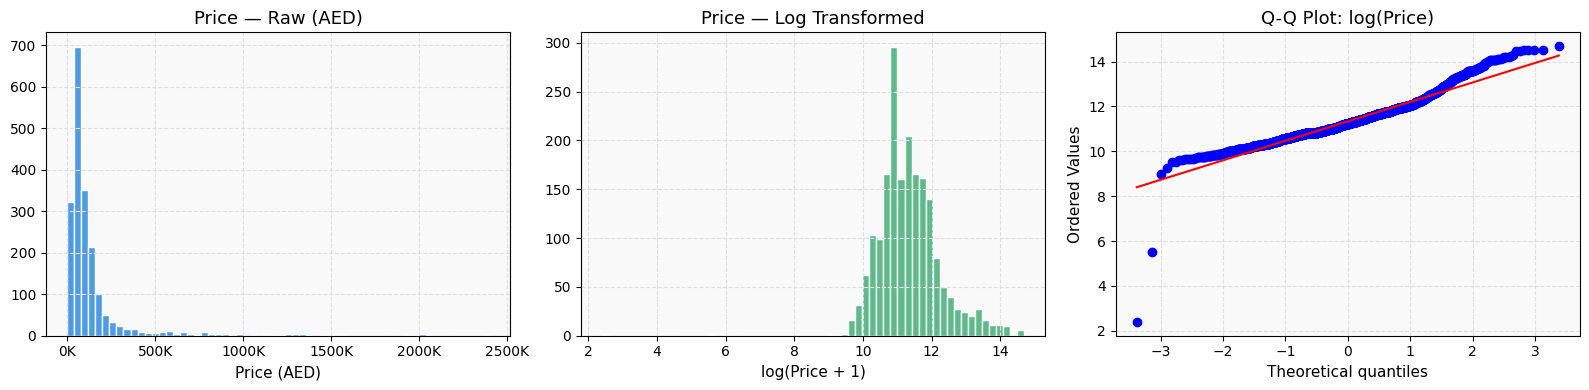

  Saved: 01_price_distribution.png


In [ ]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df["price"].dropna(), bins=60, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Price — Raw (AED)")
axes[0].set_xlabel("Price (AED)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

axes[1].hist(df["log_price"].dropna(), bins=60, color="#5DBB8A", edgecolor="white")
axes[1].set_title("Price — Log Transformed")
axes[1].set_xlabel("log(Price + 1)")

stats.probplot(df["log_price"].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot: log(Price)")

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/01_price_distribution.png", dpi=150)
plt.close()
print("  Saved: 01_price_distribution.png")

In [ ]:
print(f"Raw price skewness : {df['price'].skew():.3f}")
print(f"Log price skewness : {df['log_price'].skew():.3f}")

Raw price skewness : 4.990
Log price skewness : 0.160


In [ ]:
# Check what those extreme low price listings are
print(df.nsmallest(5, "price")[[ "model_year", "price", "mileage(km)"]])

      model_year    price  mileage(km)
1776        2026     10.0          NaN
1285        2025    250.0          NaN
1383        2011   8000.0     217467.0
912         2012  10500.0     200000.0
1001        2019  13500.0     242683.0


In [ ]:
df = df[df["price"] > 1000].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")  # should be 1973

Rows remaining: 1934


In [ ]:
print("\n─── 4. MILEAGE ───")
print(df["mileage(km)"].describe().round(2))
low_mileage_20 = (df["mileage(km)"] < 20).sum()
low_mileage_5  = (df["mileage(km)"] < 5).sum()
high_mileage   = (df["mileage(km)"] > 300000).sum()
print(f"\nEntries with mileage < 20 km  : {low_mileage_20} ({low_mileage_20/len(df)*100:.1f}%)")
print(f"Entries with mileage < 5 km   : {low_mileage_5} ({low_mileage_5/len(df)*100:.1f}%)")
print(f"Entries with mileage > 300k km: {high_mileage} ({high_mileage/len(df)*100:.1f}%)\n")



─── 4. MILEAGE ───
count      1797.00
mean      72510.57
std       58139.50
min           1.00
25%       27918.00
50%       62000.00
75%      100000.00
max      354000.00
Name: mileage(km), dtype: float64

Entries with mileage < 20 km  : 33 (1.7%)
Entries with mileage < 5 km   : 3 (0.2%)
Entries with mileage > 300k km: 5 (0.3%)



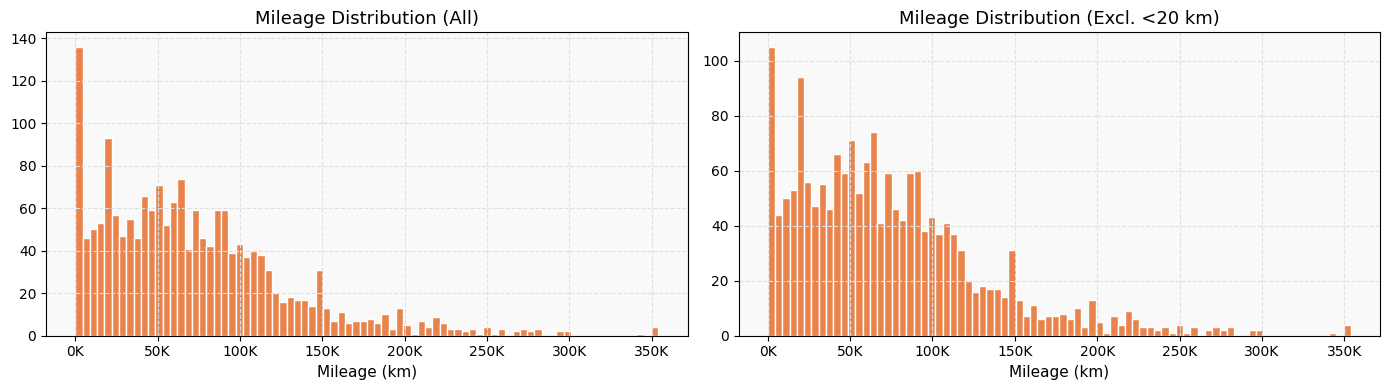

  Saved: 02_mileage_distribution.png


In [ ]:
#Flow-mileage entries
df["low_mileage_flag"] = df["mileage(km)"] < 20

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["mileage(km)"].dropna(), bins=80, color="#E8834C", edgecolor="white")
axes[0].set_title("Mileage Distribution (All)")
axes[0].set_xlabel("Mileage (km)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

axes[1].hist(df[df["mileage(km)"] >= 20]["mileage(km)"], bins=80, color="#E8834C", edgecolor="white")
axes[1].set_title("Mileage Distribution (Excl. <20 km)")
axes[1].set_xlabel("Mileage (km)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/02_mileage_distribution.png", dpi=150)
plt.close()
print("  Saved: 02_mileage_distribution.png")

In [ ]:
print((df["mileage(km)"] > 300000).sum())
print(df[df["mileage(km)"] > 300000][["model_year", "price", "mileage(km)"]].sort_values("mileage(km)", ascending=False).head(10))

5
      model_year    price  mileage(km)
1405        2018  36900.0     354000.0
958         2013  29000.0     350000.0
987         2013  29000.0     350000.0
1882        2013  41000.0     350000.0
1170        2014  18000.0     341000.0


─── 5. CAR AGE ───
count    1934.00
mean        4.16
std         3.11
min         0.00
25%         2.00
50%         3.00
75%         6.00
max        15.00
Name: car_age, dtype: float64 



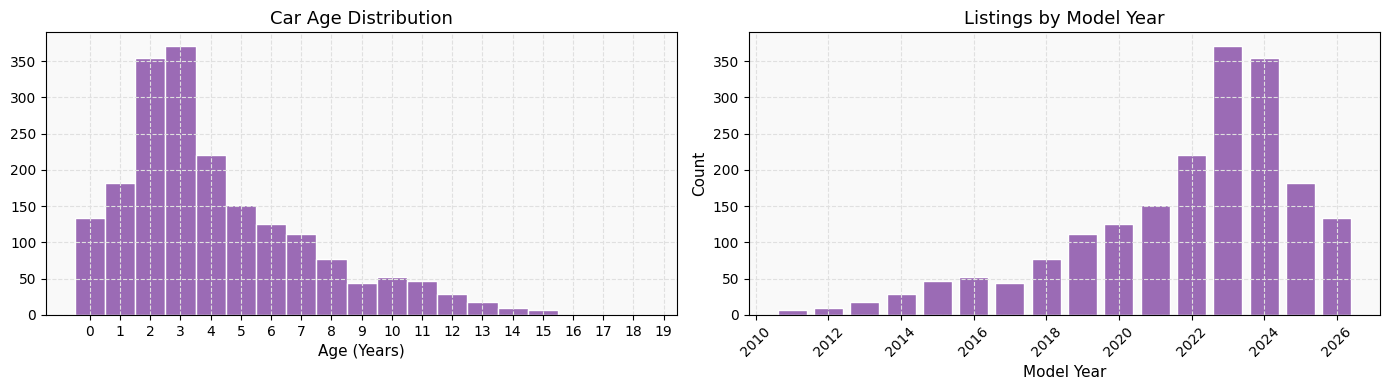

  Saved: 03_age_model_year.png


In [ ]:
print("─── 5. CAR AGE ───")
print(df["car_age"].describe().round(2), "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["car_age"].dropna(), bins=range(0, 20), color="#9B6BB5", edgecolor="white", align="left")
axes[0].set_title("Car Age Distribution")
axes[0].set_xlabel("Age (Years)")
axes[0].set_xticks(range(0, 20))

# Model year distribution
yr_counts = df["model_year"].value_counts().sort_index()
axes[1].bar(yr_counts.index, yr_counts.values, color="#9B6BB5", edgecolor="white")
axes[1].set_title("Listings by Model Year")
axes[1].set_xlabel("Model Year")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/03_age_model_year.png", dpi=150)
plt.close()
print("  Saved: 03_age_model_year.png")


In [ ]:
print(df.columns.tolist())

['car_title', 'price', 'model_year', 'mileage(km)', 'monthly_payment', 'specs', 'location', 'fuel_type', 'transmission', 'deal_rating', 'semiconductor_flag', 'market_period', 'car_age', 'financing_available', 'full_service_history', 'inspected', 'under_warranty', 'urgent_sale', 'export_options', 'helper', 'inflation', 'oil_price', 'conflict_index', 'age_inflation_interaction', 'age_conflict_interaction', 'age_semiconductor_interaction', 'mileage_oil_interaction', 'log_price', 'low_mileage_flag']


In [ ]:
print(df["market_period"].unique())

['Post-Recovery' 'Recovery' 'COVID Period' 'Pre-COVID' 'Shortage Peak'
 'Oil Price Crash' 'Conflict Period 2026' 'Pre-Crash Stable']


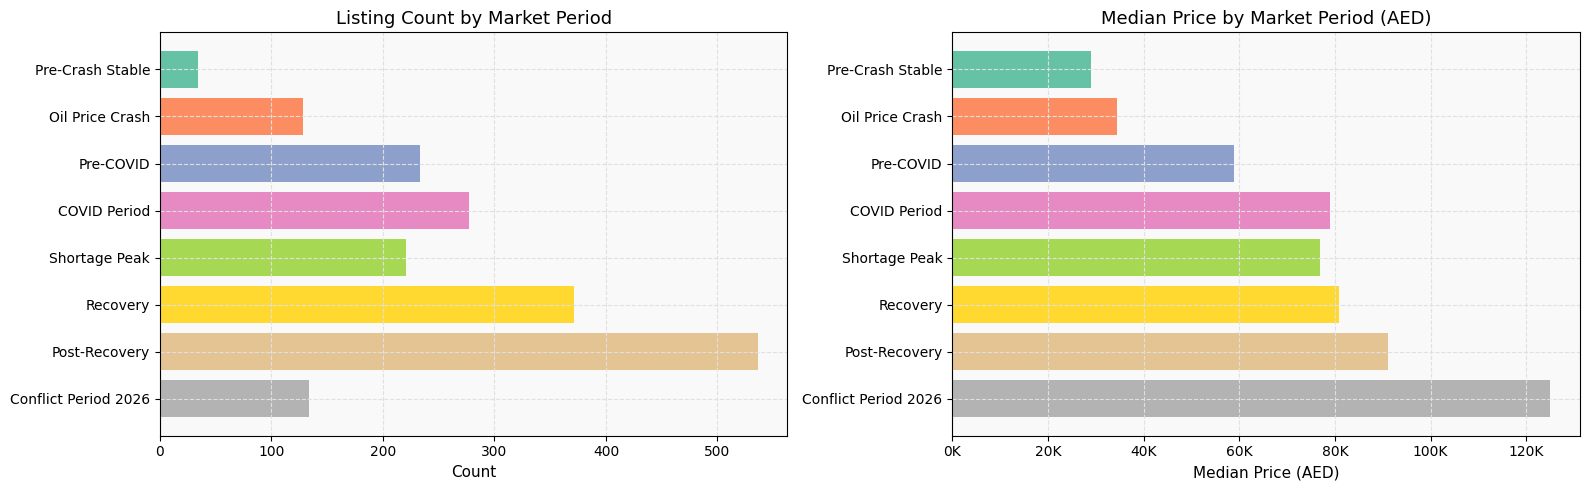

  Saved: 04_market_period.png


In [ ]:
period_order = [
    "Pre-Crash Stable",
    "Oil Price Crash",
    "Pre-COVID",
    "COVID Period",
    "Shortage Peak",
    "Recovery",
    "Post-Recovery",
    "Conflict Period 2026",
]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Count per period
counts_ordered = df["market_period"].value_counts().reindex(period_order, fill_value=0)
axes[0].barh(counts_ordered.index, counts_ordered.values,
             color=sns.color_palette(PALETTE, len(counts_ordered)))
axes[0].set_title("Listing Count by Market Period")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# Median price per period
med_price = df.groupby("market_period")["price"].median().reindex(period_order)
axes[1].barh(med_price.index, med_price.values,
             color=sns.color_palette(PALETTE, len(med_price)))
axes[1].set_title("Median Price by Market Period (AED)")
axes[1].set_xlabel("Median Price (AED)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/04_market_period.png", dpi=150)
plt.close()
print("  Saved: 04_market_period.png")

In [ ]:
print(df["market_period"].value_counts())

market_period
Post-Recovery           536
Recovery                371
COVID Period            277
Pre-COVID               233
Shortage Peak           221
Conflict Period 2026    134
Oil Price Crash         128
Pre-Crash Stable         34
Name: count, dtype: int64


─── 7. PRICE vs AGE / MILEAGE ───


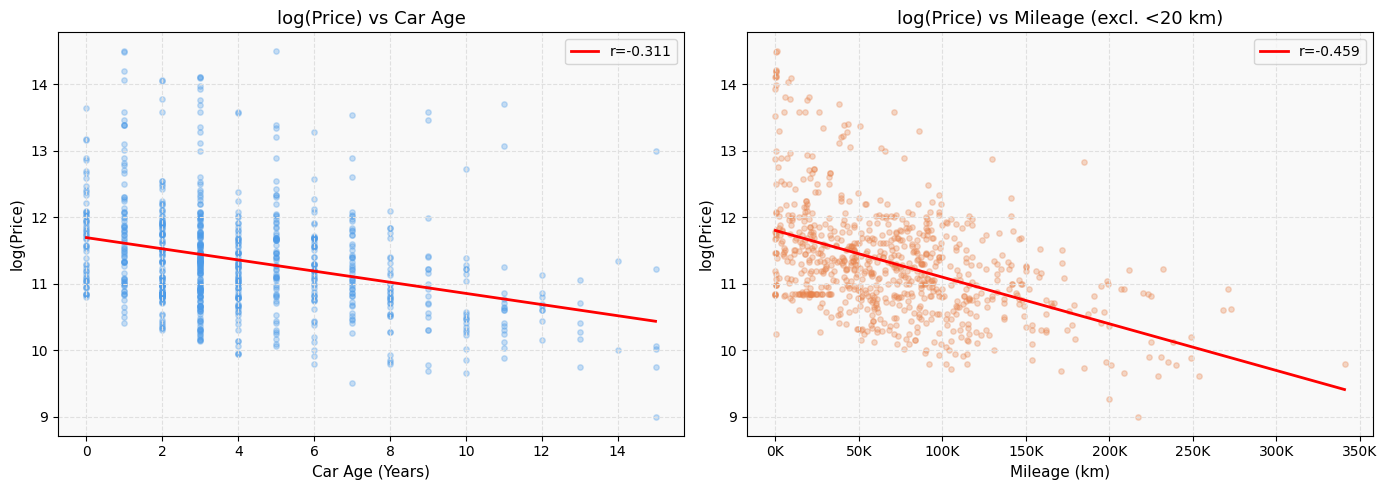

  Price vs Age: r = -0.311  |  Price vs Mileage: r = -0.459
  Saved: 05_price_vs_age_mileage.png


In [ ]:
print("─── 7. PRICE vs AGE / MILEAGE ───")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price vs Car Age (scatter + trend)
sample = df[["car_age", "log_price"]].dropna().sample(min(800, len(df)), random_state=42)
axes[0].scatter(sample["car_age"], sample["log_price"], alpha=0.3, s=15, color="#4C9BE8")
m, b, r, p, _ = stats.linregress(sample["car_age"], sample["log_price"])
x_line = np.linspace(sample["car_age"].min(), sample["car_age"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="red", linewidth=2, label=f"r={r:.3f}")
axes[0].set_title("log(Price) vs Car Age")
axes[0].set_xlabel("Car Age (Years)")
axes[0].set_ylabel("log(Price)")
axes[0].legend()

# Price vs Mileage (excl. <20 km outliers for clarity)
sample2 = df[df["mileage(km)"] >= 20][["mileage(km)", "log_price"]].dropna().sample(min(800, len(df)), random_state=42)
axes[1].scatter(sample2["mileage(km)"], sample2["log_price"], alpha=0.3, s=15, color="#E8834C")
m2, b2, r2, p2, _ = stats.linregress(sample2["mileage(km)"], sample2["log_price"])
x2 = np.linspace(sample2["mileage(km)"].min(), sample2["mileage(km)"].max(), 100)
axes[1].plot(x2, m2 * x2 + b2, color="red", linewidth=2, label=f"r={r2:.3f}")
axes[1].set_title("log(Price) vs Mileage (excl. <20 km)")
axes[1].set_xlabel("Mileage (km)")
axes[1].set_ylabel("log(Price)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/05_price_vs_age_mileage.png", dpi=150)
plt.close()
print(f"  Price vs Age: r = {r:.3f}  |  Price vs Mileage: r = {r2:.3f}")
print("  Saved: 05_price_vs_age_mileage.png")



─── 8. DEPRECIATION CURVE BY ERA ───


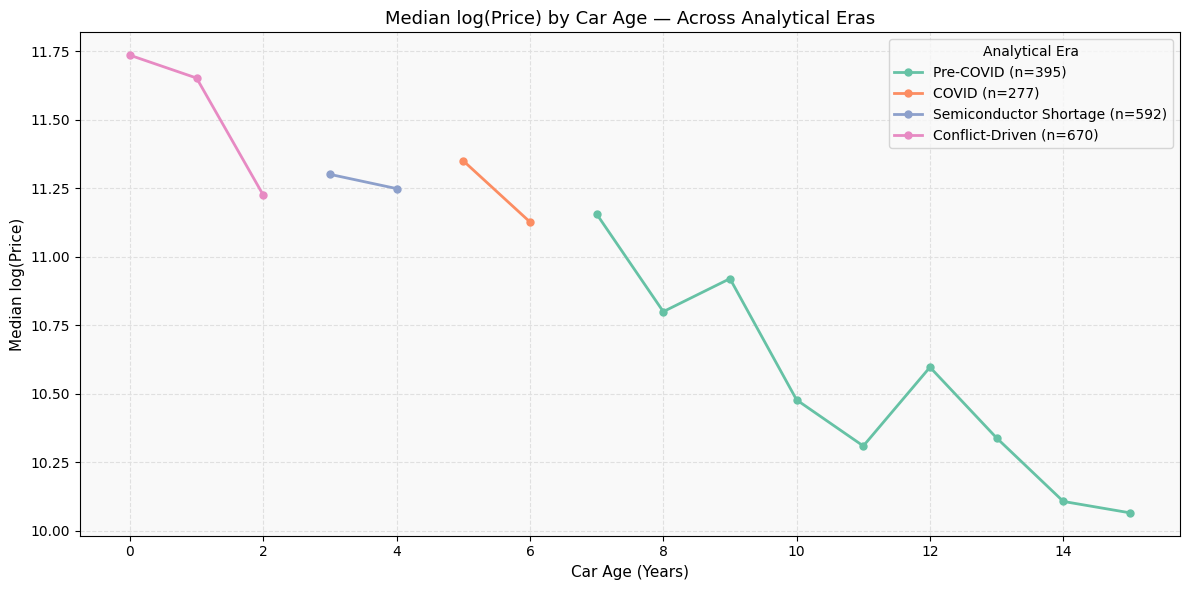

  Saved: 06_depreciation_by_era.png


In [ ]:
print("\n─── 8. DEPRECIATION CURVE BY ERA ───")

# Map 8 periods to 4 analytical eras
era_map = {
    "Pre-Crash Stable":      "Pre-COVID",
    "Oil Price Crash":       "Pre-COVID",
    "Pre-COVID":             "Pre-COVID",
    "COVID Period":          "COVID",
    "Shortage Peak":         "Semiconductor Shortage",
    "Recovery":              "Semiconductor Shortage",
    "Post-Recovery":         "Conflict-Driven",
    "Conflict Period 2026":  "Conflict-Driven",
}
df["analytical_era"] = df["market_period"].map(era_map)

era_order = ["Pre-COVID", "COVID", "Semiconductor Shortage", "Conflict-Driven"]
era_colors = dict(zip(era_order, sns.color_palette(PALETTE, 4)))

fig, ax = plt.subplots(figsize=(12, 6))
for era in era_order:
    subset = df[df["analytical_era"] == era][["car_age", "log_price"]].dropna()
    if len(subset) < 10:
        print(f"  WARNING: '{era}' has only {len(subset)} rows — trend line may be unreliable")
        continue
    grouped = subset.groupby("car_age")["log_price"].median().reset_index()
    ax.plot(grouped["car_age"], grouped["log_price"],
            marker="o", markersize=5, linewidth=2,
            label=f"{era} (n={len(subset)})", color=era_colors[era])

ax.set_title("Median log(Price) by Car Age — Across Analytical Eras")
ax.set_xlabel("Car Age (Years)")
ax.set_ylabel("Median log(Price)")
ax.legend(title="Analytical Era")
plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/06_depreciation_by_era.png", dpi=150)
plt.close()
print("  Saved: 06_depreciation_by_era.png")


─── 9. MACRO VARIABLES ───
inflation: min=-2.08, max=5.29, mean=1.62, missing=0
oil_price: min=41.56, max=111.57, mean=77.17, missing=0
conflict_index: min=30.87, max=100.00, mean=76.12, missing=197


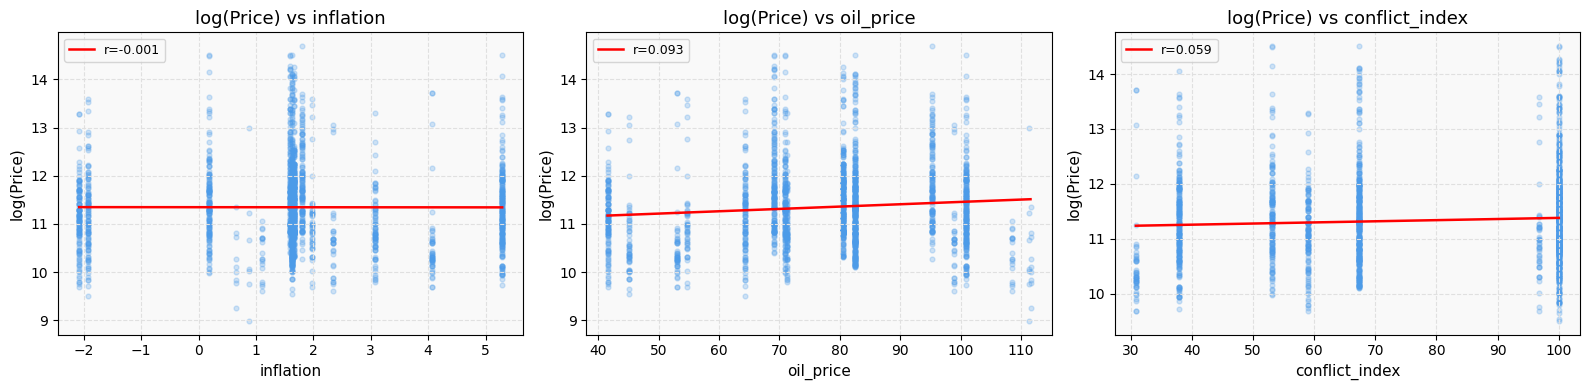

  Saved: 07_macro_vs_price.png


In [ ]:
print("\n─── 9. MACRO VARIABLES ───")

macro_vars = ["inflation", "oil_price", "conflict_index"]
for v in macro_vars:
    if v in df.columns:
        n_missing = df[v].isnull().sum()
        print(f"{v}: min={df[v].min():.2f}, max={df[v].max():.2f}, "
              f"mean={df[v].mean():.2f}, missing={n_missing}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, v in enumerate(macro_vars):
    if v not in df.columns:
        continue
    clean = df[[v, "log_price"]].dropna()
    axes[i].scatter(clean[v], clean["log_price"], alpha=0.25, s=12, color="#4C9BE8")
    if len(clean) > 10:
        m, b, r, _, _ = stats.linregress(clean[v], clean["log_price"])
        x_r = np.linspace(clean[v].min(), clean[v].max(), 100)
        axes[i].plot(x_r, m * x_r + b, color="red", linewidth=1.8, label=f"r={r:.3f}")
        axes[i].legend(fontsize=9)
    axes[i].set_title(f"log(Price) vs {v}")
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("log(Price)")

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/07_macro_vs_price.png", dpi=150)
plt.close()
print("  Saved: 07_macro_vs_price.png")



─── 10. CATEGORICAL DISTRIBUTIONS ───
  Saved: 08_categorical_distributions.png


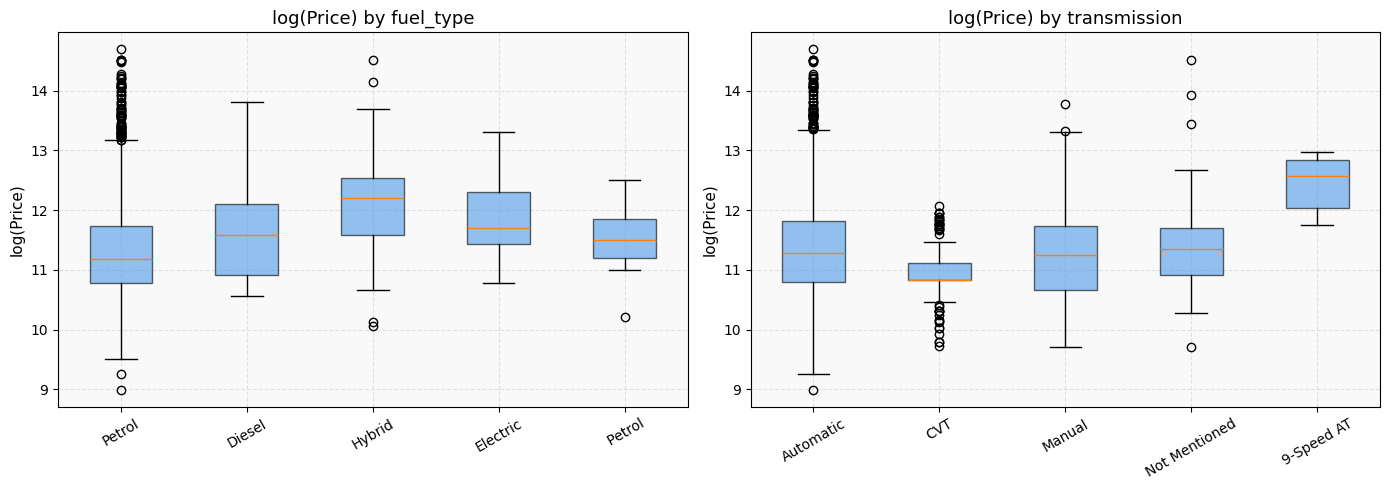

  Saved: 09_price_by_category.png


In [ ]:
print("\n─── 10. CATEGORICAL DISTRIBUTIONS ───")

cat_cols = ["fuel_type", "transmission", "specs", "location", "deal_rating"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    order = df[col].value_counts().index[:10]  # top 10 categories
    counts = df[col].value_counts().reindex(order)
    axes[i].barh(counts.index, counts.values,
                 color=sns.color_palette(PALETTE, len(counts)))
    axes[i].set_title(f"{col} — Count")
    axes[i].invert_yaxis()

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig("eda_outputs/08_categorical_distributions.png", dpi=150)
plt.close()
print("  Saved: 08_categorical_distributions.png")

# Price by fuel type and transmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(["fuel_type", "transmission"]):
    if col not in df.columns:
        continue
    order = df[col].value_counts().index
    data_to_plot = [df[df[col] == c]["log_price"].dropna().values for c in order]
    axes[i].boxplot(data_to_plot, labels=order, patch_artist=True,
                    boxprops=dict(facecolor="#4C9BE8", alpha=0.6))
    axes[i].set_title(f"log(Price) by {col}")
    axes[i].set_ylabel("log(Price)")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/09_price_by_category.png", dpi=150)
plt.close()
print("  Saved: 09_price_by_category.png")




─── 11. BINARY FLAGS ───
  financing_available: {0: 1825, 1: 109}
  full_service_history: {0: 1897, 1: 37}
  inspected: {0: 1836, 1: 98}
  under_warranty: {0: 1323, 1: 611}
  urgent_sale: {0: 1799, 1: 135}
  export_options: {'Not Applicable': 991, 'Can Be Exported': 504, 'Not For Export': 430, 'Only For Export': 9}
  semiconductor_flag: {0: 1191, 1: 743}



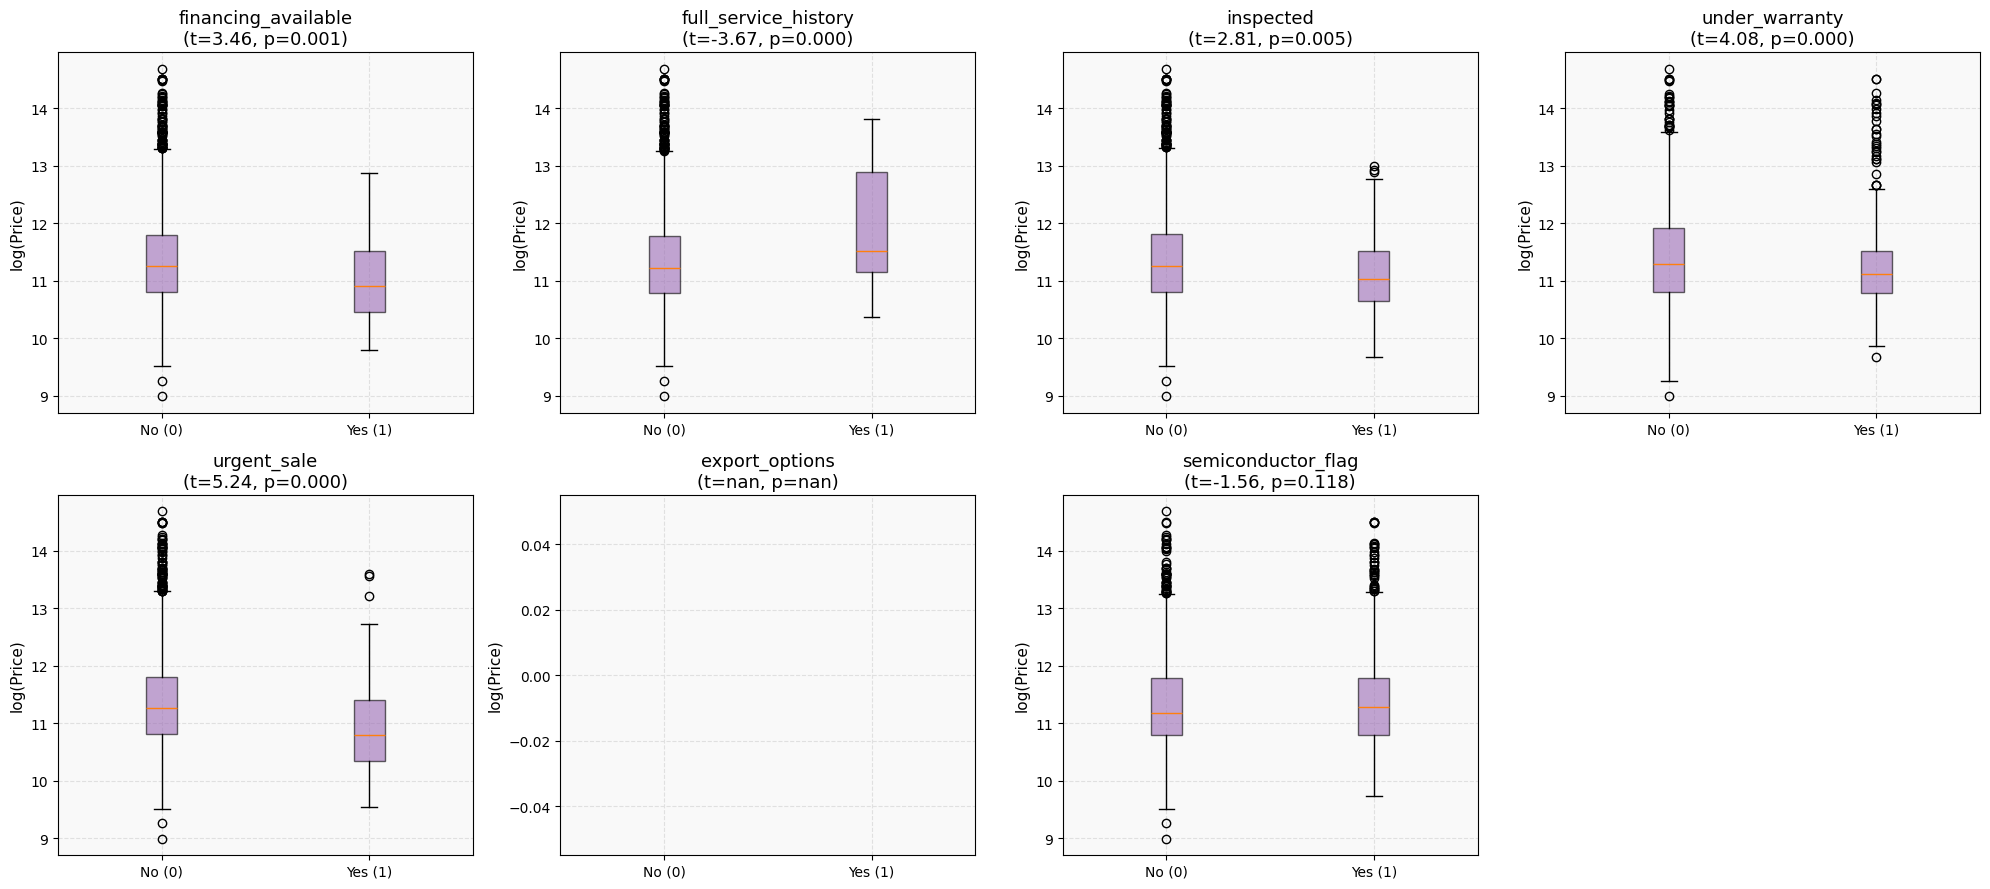

  Saved: 10_binary_flags_price.png


In [ ]:
print("\n─── 11. BINARY FLAGS ───")

binary_cols = [
    "financing_available", "full_service_history", "inspected",
    "under_warranty", "urgent_sale", "export_options", "semiconductor_flag"
]
binary_cols = [c for c in binary_cols if c in df.columns]

summary_rows = []
for col in binary_cols:
    val_counts = df[col].value_counts(dropna=False)
    pct_yes = (df[col] == 1).sum() / len(df) * 100
    summary_rows.append({"Flag": col, "Count_1": (df[col] == 1).sum(),
                          "Count_0": (df[col] == 0).sum(), "% Yes": round(pct_yes, 1)})
    print(f"  {col}: {val_counts.to_dict()}")

print()

# Price difference by each flag
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    group0 = df[df[col] == 0]["log_price"].dropna()
    group1 = df[df[col] == 1]["log_price"].dropna()
    axes[i].boxplot([group0.values, group1.values], labels=["No (0)", "Yes (1)"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#9B6BB5", alpha=0.6))
    t, p = stats.ttest_ind(group0, group1)
    axes[i].set_title(f"{col}\n(t={t:.2f}, p={p:.3f})")
    axes[i].set_ylabel("log(Price)")

for j in range(len(binary_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/10_binary_flags_price.png", dpi=150)
plt.close()
print("  Saved: 10_binary_flags_price.png")

In [ ]:
monthly_payment_num = pd.to_numeric(
    df["monthly_payment"].astype(str).str.replace(r"[^\d.\-]", "", regex=True),
    errors="coerce"
)

In [ ]:
print("─── 12. MONTHLY PAYMENT / FINANCING CONSISTENCY CHECK ───")

if "monthly_payment" in df.columns and "financing_available" in df.columns:
    monthly_payment_num = pd.to_numeric(df["monthly_payment"], errors="coerce")
    financing_num = pd.to_numeric(df["financing_available"], errors="coerce")

    has_payment = monthly_payment_num.notna() & (monthly_payment_num > 0)

    mismatch = ((has_payment) & (financing_num == 0)).sum()
    mismatch2 = ((~has_payment) & (financing_num == 1)).sum()

    print(f"  Has monthly_payment but Financing_Available=0: {mismatch} rows")
    print(f"  No monthly_payment but Financing_Available=1 : {mismatch2} rows")
    print(f"  => monthly_payment should NOT be used as a direct predictor in regression.\n")

─── 12. MONTHLY PAYMENT / FINANCING CONSISTENCY CHECK ───
  Has monthly_payment but Financing_Available=0: 1396 rows
  No monthly_payment but Financing_Available=1 : 60 rows
  => monthly_payment should NOT be used as a direct predictor in regression.



─── 13. CORRELATION HEATMAP ───
mileage_oil_interaction         -0.419308
car_age                         -0.345958
age_conflict_interaction        -0.224998
age_inflation_interaction       -0.166615
inflation                       -0.001375
age_semiconductor_interaction    0.037239
conflict_index                   0.059392
oil_price                        0.093368
log_price                        1.000000
Name: log_price, dtype: float64 



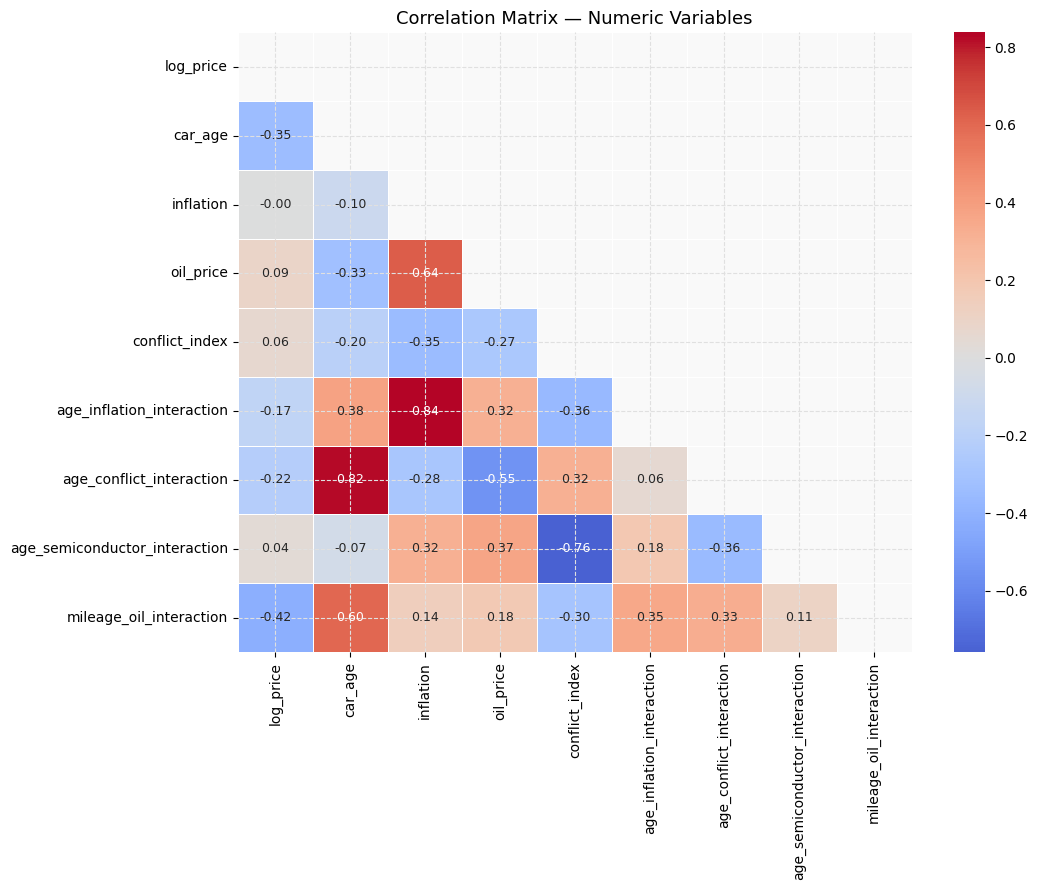

  Saved: 11_correlation_heatmap.png


In [ ]:
print("─── 13. CORRELATION HEATMAP ───")

num_cols = [
    "log_price", "car_age", "mileage_km", "inflation", "oil_price",
    "conflict_index", "age_inflation_interaction", "age_conflict_interaction",
    "age_semiconductor_interaction", "mileage_oil_interaction"
]
num_cols = [c for c in num_cols if c in df.columns]

corr_df = df[num_cols].corr()
print(corr_df["log_price"].sort_values(), "\n")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation Matrix — Numeric Variables")
plt.tight_layout()
plt.show()
plt.savefig("eda_outputs/11_correlation_heatmap.png", dpi=150)
plt.close()
print("  Saved: 11_correlation_heatmap.png")

In [ ]:
print("─── 14. VIF CHECK ───")
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_cols = [c for c in num_cols if c != "log_price"]
    vif_data = df[vif_cols].dropna()
    vif_results = pd.DataFrame({
        "Feature": vif_cols,
        "VIF": [variance_inflation_factor(vif_data.values, i)
                for i in range(len(vif_cols))]
    }).sort_values("VIF", ascending=False)
    print(vif_results.to_string(index=False))
    print("\n  VIF > 10 = severe multicollinearity concern\n")
except ImportError:
    print("  statsmodels not installed — skipping VIF. Run: pip install statsmodels\n")

─── 14. VIF CHECK ───
                      Feature        VIF
                    oil_price 209.889770
               conflict_index  85.492887
                    inflation  70.437673
                      car_age  53.585851
    age_inflation_interaction  37.374518
     age_conflict_interaction  33.070178
age_semiconductor_interaction   9.698569
      mileage_oil_interaction   4.791261

  VIF > 10 = severe multicollinearity concern



In [ ]:
print("─── 15. DESCRIPTIVE STATISTICS TABLE ───")
desc = df[["price", "log_price", "car_age", "mileage(km)",
           "inflation", "oil_price", "conflict_index"]].describe().round(2)
print(desc)
desc.to_csv("eda_outputs/descriptive_stats.csv")
print("\n  Saved: descriptive_stats.csv")

print(f"\n{'='*60}")
print("  EDA COMPLETE — all outputs saved to ./eda_outputs/")
print(f"{'='*60}\n")

─── 15. DESCRIPTIVE STATISTICS TABLE ───
            price  log_price  car_age  mileage(km)  inflation  oil_price  conflict_index
count     1934.00    1934.00  1934.00      1797.00    1934.00    1934.00         1737.00
mean    137588.90      11.34     4.16     72510.57       1.62      77.17           76.12
std     217924.13       0.86     3.11     58139.50       1.89      16.64           24.32
min       8000.00       8.99     0.00         1.00      -2.08      41.56           30.87
25%      48999.00      10.80     2.00     27918.00       1.60      69.14           58.98
50%      75549.50      11.23     3.00     62000.00       1.63      80.52           67.35
75%     131774.25      11.79     6.00    100000.00       1.80      82.49          100.00
max    2399000.00      14.69    15.00    354000.00       5.29     111.57          100.00

  Saved: descriptive_stats.csv

  EDA COMPLETE — all outputs saved to ./eda_outputs/



EDA Completed